In [1]:
#!pip install nsepy  (National Stock Exchange of India)  Python library to get publicly available data

In [2]:
#!pip install yfinance  (yahoo finance -it provides the stock market data, company information,hisorical prices)

In [3]:
from Descriptive import Descriptive

In [4]:
obj=Descriptive()

In [5]:
import yfinance as yf
stock=yf.download("RELIANCE.NS",start="2020-1-1",end="2023-12-31")
print(stock.head())

[*********************100%***********************]  1 of 1 completed

Price            Close        High         Low        Open      Volume
Ticker     RELIANCE.NS RELIANCE.NS RELIANCE.NS RELIANCE.NS RELIANCE.NS
Date                                                                  
2020-01-01  672.216187  680.008852  670.390532  675.956671    14004468
2020-01-02  683.660278  686.176208  673.284921  673.284921    17710316
2020-01-03  684.484131  686.487957  678.183188  682.636123    20984698
2020-01-06  668.609314  680.365044  667.050769  676.847260    24519177
2020-01-07  678.895569  683.303975  673.952766  676.401873    16683622


In [6]:
stock.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 992 entries, 2020-01-01 to 2023-12-29
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   (Close, RELIANCE.NS)   992 non-null    float64
 1   (High, RELIANCE.NS)    992 non-null    float64
 2   (Low, RELIANCE.NS)     992 non-null    float64
 3   (Open, RELIANCE.NS)    992 non-null    float64
 4   (Volume, RELIANCE.NS)  992 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 46.5 KB


In [7]:
stock

Price,Close,High,Low,Open,Volume
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
Date,,,,,
2020-01-01,672.216187,680.008852,670.390532,675.956671,14004468
2020-01-02,683.660278,686.176208,673.284921,673.284921,17710316
2020-01-03,684.484131,686.487957,678.183188,682.636123,20984698
2020-01-06,668.609314,680.365044,667.050769,676.847260,24519177
2020-01-07,678.895569,683.303975,673.952766,676.401873,16683622
...,...,...,...,...,...
2023-12-22,1267.243042,1275.073539,1258.646635,1264.550536,16541784
2023-12-26,1273.665527,1280.532666,1266.081931,1268.700379,7465664


In [8]:
low=stock["Low"]

In [9]:
dataset=stock

In [10]:
dataset.columns = dataset.columns.get_level_values(0)  #for removing multi index
print(dataset.columns)


Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='str', name='Price')


In [11]:
quan,qual=obj.segreQuanQual(dataset)

The Quantative data: ['Close', 'High', 'Low', 'Open', 'Volume']
The Qualtative data: []


In [12]:
des_data=obj.descriptive_analysis(dataset,quan)

In [13]:
des_data

,Close,High,Low,Open,Volume
Null_count,0,0,0,0,0
NonNull_count,992,992,992,992,992
Total_Count,992,992,992,992,992
Mean,1017.525989,1029.049282,1006.955488,1018.388359,21068452.832661
Median,1075.504333,1087.5127,1064.865901,1075.815823,15207348.5
Mode,862.586975,423.029567,389.92193,407.978604,1705656
Std,184.512804,184.037123,184.632588,184.364655,17353435.169762
Min,393.662415,423.029567,389.92193,407.978604,1705656.0
Q1:25%,915.580399,930.192693,903.055608,917.413931,10748759.5
Q2:50%,1075.504333,1087.5127,1064.865901,1075.815823,15207348.5


In [14]:
des_data["Low"]

Null_count                 0
NonNull_count            992
Total_Count              992
Mean             1006.955488
Median           1064.865901
Mode               389.92193
Std               184.632588
Min                389.92193
Q1:25%            903.055608
Q2:50%           1064.865901
Q3:75%           1146.050469
Q4:100%          1278.013265
IQR               242.994861
1.5Rule           364.492291
Lesser            538.563317
Greater           1510.54276
Name: Low, dtype: object

In [15]:
des_data["High"]

Null_count                 0
NonNull_count            992
Total_Count              992
Mean             1029.049282
Median             1087.5127
Mode              423.029567
Std               184.037123
Min               423.029567
Q1:25%            930.192693
Q2:50%             1087.5127
Q3:75%           1165.266458
Q4:100%           1297.75409
IQR               235.073766
1.5Rule           352.610649
Lesser            577.582044
Greater          1517.877107
Name: High, dtype: object

In [16]:
import numpy as np

In [17]:
np.percentile(dataset["Low"],99)

np.float64(1256.0475598895903)

In [18]:
np.percentile(dataset["High"],80)

np.float64(1181.0575227694817)

In [19]:
#!pip install matplotlib


In [20]:
#!pip install seaborn

In [21]:
def get_pdf_probability(dataset,startrange,endrange):
    from matplotlib import pyplot
    from scipy.stats import norm
    import seaborn as sns
    ax=sns.distplot(dataset,kde=True,kde_kws={'color':'blue'},color='Green')
    pyplot.axvline(startrange,color='Red')
    pyplot.axvline(endrange,color='Red')

    sample=dataset
    sample_mean=sample.mean()
    sample_std=sample.std()

    print('Mean=%.3f, Standard Deviation=%.3f'%(sample_mean,sample_std))

    dist=norm(sample_mean,sample_std)
    values=[value for value in range(startrange,endrange)]
    probabilities=[dist.pdf(value) for value in values]
    prob=sum(probabilities)
    print("The area between range({},{}):{}".format(startrange,endrange,sum(probabilities)))
    return prob

    
    

Mean=1006.955, Standard Deviation=184.633
The area between range(509,569):0.005310543828014959


C:\Users\Sathish\AppData\Local\Temp\ipykernel_14712\1423209952.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  ax=sns.distplot(dataset,kde=True,kde_kws={'color':'blue'},color='Green')


np.float64(0.005310543828014959)

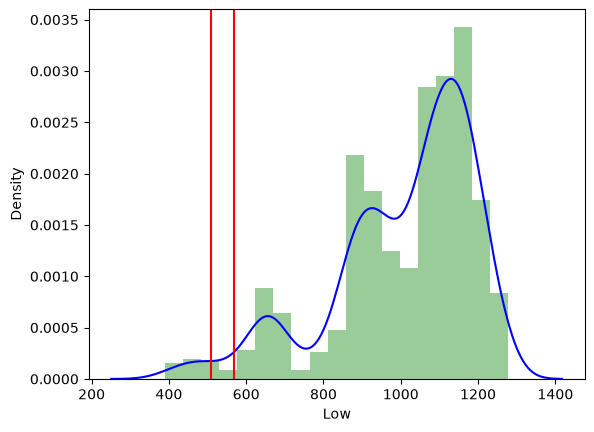

In [22]:
get_pdf_probability(dataset["Low"],509,569)

In [23]:
#!pip install scipy

In [24]:
def stdNBgraph(dataset):
    #converted to standard normal distribution
    import seaborn as sns
    mean=dataset.mean()
    std=dataset.std()
    values=[i for i in dataset]
    z_score=[((j-mean)/std) for j in values]

    sns.distplot(z_score,kde=True)

    sum(z_score)/len(z_score)

C:\Users\Sathish\AppData\Local\Temp\ipykernel_14712\231606848.py:9: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(z_score,kde=True)


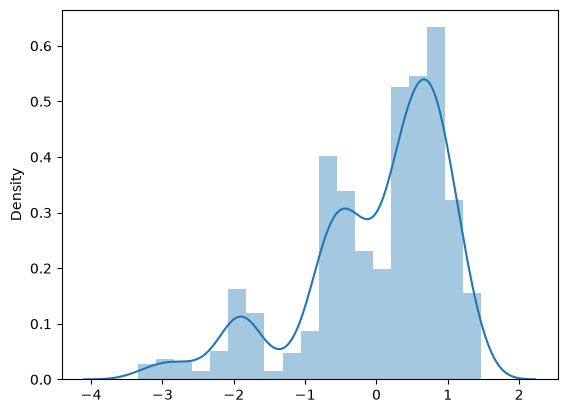

In [25]:
stdNBgraph(dataset["Low"])

In [26]:
def freqTable(columnName,dataset):
    import pandas as pd
    frq=pd.DataFrame()
    frq["Unique_Values"]=dataset[columnName].value_counts().index
    frq["Frequency"]=dataset[columnName].value_counts().values
    frq["Relative_Fre"]=dataset[columnName].value_counts().values/len(dataset[columnName])*100
    frq["Cumulative"]=frq["Relative_Fre"].cumsum()
    return frq

In [27]:
freqTable("Low",dataset)

,Unique_Values,Frequency,Relative_Fre,Cumulative
0,670.390532,1,0.100806,0.100806
1,673.284921,1,0.100806,0.201613
2,678.183188,1,0.100806,0.302419
3,667.050769,1,0.100806,0.403226
4,673.952766,1,0.100806,0.504032
...,...,...,...,...
987,1258.646635,1,0.100806,99.596774
988,1266.081931,1,0.100806,99.697581
989,1271.220103,1,0.100806,99.798387
990,1278.013265,1,0.100806,99.899194


In [28]:
freqTable("High",dataset)

,Unique_Values,Frequency,Relative_Fre,Cumulative
0,680.008852,1,0.100806,0.100806
1,686.176208,1,0.100806,0.201613
2,686.487957,1,0.100806,0.302419
3,680.365044,1,0.100806,0.403226
4,683.303975,1,0.100806,0.504032
...,...,...,...,...
987,1275.073539,1,0.100806,99.596774
988,1280.532666,1,0.100806,99.697581
989,1284.460338,1,0.100806,99.798387
990,1290.438379,1,0.100806,99.899194


In [29]:
fh=freqTable("High",dataset)

In [30]:
fh.sort_values(by="Frequency",ascending=False)

,Unique_Values,Frequency,Relative_Fre,Cumulative
0,680.008852,1,0.100806,0.100806
1,686.176208,1,0.100806,0.201613
2,686.487957,1,0.100806,0.302419
3,680.365044,1,0.100806,0.403226
4,683.303975,1,0.100806,0.504032
...,...,...,...,...
987,1275.073539,1,0.100806,99.596774
988,1280.532666,1,0.100806,99.697581
989,1284.460338,1,0.100806,99.798387
990,1290.438379,1,0.100806,99.899194


In [31]:
fhs=fh[fh["Frequency"]==1]["Unique_Values"].sort_values(ascending=False)

In [32]:
fhs

881    1297.754090
882    1295.225114
578    1293.601566
991    1291.426414
577    1291.269050
          ...     
53      461.280325
55      460.834992
57      431.935392
54      430.599519
56      423.029567
Name: Unique_Values, Length: 992, dtype: float64